## 3/25 Tests on a global dataset

Problem: If the transect requires that you move along land, how do you prevent the transect from moving the incorrect direction?
The examples below show that the ```vertexOnEdge``` closest to the endpoint is north of the current vertex. However, it looks like moving east along land would actually be faster, even if the eastern ```vertexOnEdge``` of the current vertex is farther away from the endpoint. This problem is likely why the code breaks for ```count >= 347``` because the transect wants to double back but it cannot because the ```calculate_transects``` funciton only allows vertices to be traveled to once. However, allowing vertices to be doubled back on also doesn't seem to fix the problem, since this allows the transect to just go in circles. 

So my conclusion/question is if this is a problem that actually needs to be addressed, or do we assume the user will not choose this technical of a mask to make, where the transect must move around a lot of land?


In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
#Packages 
import numpy as np
import xarray as xr
import cmocean.cm as cmo
import matplotlib.pyplot as plt
import mpas_tools

from geometric_features import GeometricFeatures
from geometric_features import read_feature_collection

from mpas_tools.mesh.mask import compute_mpas_region_masks
from mpas_tools.parallel import create_pool
from mpas_tools.io import write_netcdf

import geojson
import json
import mosaic
import os.path
import mpasregions.sections as mps
import gsw
import warnings 
import glob
from xgcm import Grid

In [3]:
mesh_path = '/global/cfs/projectdirs/e3sm/inputdata/ocn/mpas-o/EC30to60E2r2/ocean.EC30to60E2r2.210210.nc'
mesh = xr.open_dataset(mesh_path)
mesh = mesh.assign_coords({
"VertexID": xr.DataArray(mesh.indexToVertexID, dims=('nVertices',)),
})

In [4]:
# open datasets with just the variables that we want
bmm_filepath = '/pscratch/sd/b/bmoorema/run_001_062/'

months = ['01','02','03','04','05','06','07','08','09','10','11','12']
ds_list = []

prefix = '20210421_sim7_CORE_60to30E2r2.mpaso.hist.am.timeSeriesStats'

year = 3 # int
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for i in range(0,12):
        month = months[i]
        file = prefix + f'Monthly.{str(year).zfill(4)}-{month}-01.nc'
        file_glob = glob.glob(file)
        ds = xr.open_dataset(bmm_filepath + file)[['xtime_startMonthly','timeMonthly_avg_normalVelocity','timeMonthly_avg_potentialDensity','timeMonthly_avg_layerThickness',
                                                   'nCells','nEdges','nVertLevels','nVertLevelsP1']]
        ds_xtime_startMonthly = ds.swap_dims({'Time':'xtime_startMonthly'})
        ds_list.append(ds_xtime_startMonthly)

dss = xr.concat(ds_list,dim='xtime_startMonthly')

ds = mps.add_grid_info_coords(mesh,dss)

In [5]:
# test transect algorithm
def test_calculate_transects(ds):
    from mpasregions.sections import calculate_transects
    test_edges, test_vertices = calculate_transects(-30, 90, 60, 180, ds)
    return test_edges, test_vertices

In [6]:
# # def calculate_transects(target_start_lat, target_start_lon, target_end_lat, target_end_lon, ds):

target_start_lat, target_start_lon, target_end_lat, target_end_lon = -30,90,60,180
# xr_transect_edges, next_vertices = mps.calculate_transects(target_start_lat, target_start_lon, target_end_lat, target_end_lon,ds)

In [7]:
# set up descriptor for plotting 
# # set up mesh to apply polypcolor
mesh.attrs['is_periodic'] = 'YES'
mesh.attrs['x_period'] = 360
mesh.attrs['y_period'] = 0.0

descriptor = mosaic.Descriptor(mesh,use_latlon=False)

### allow transect to double back

In [8]:
# function to calculate transect given a target start point, target end point, and ds
# def calculate_transects(target_start_lat, target_start_lon, target_end_lat, target_end_lon, ds):
# ---------- INITIATE START VERTEX ----------------
# of these transect cells, select the one that is closest to the desired starting point.
# desired values in deg
# distance_on_unit_sphere(lon1, lat1, lon2, lat 2)
# find the shortest path between the two points
# of all of the points, find the vertex that is closest to the desired start point
dist_to_start = mps.distance_on_unit_sphere(ds.lonVertex * 180/np.pi, ds.latVertex * 180/np.pi, target_start_lon, target_start_lat)
xr_start_vertex = dist_to_start.argmin()
### print('very first start vertex is ', np.int32(xr_start_vertex))
n_start_vertex = mps.xr_to_n_idx(xr_start_vertex)

start_lon = ds.isel(nVertices = xr_start_vertex).lonVertex * 180/np.pi
start_lat = ds.isel(nVertices = xr_start_vertex).latVertex * 180/np.pi

# repeat to find the vertex that is closest to the desired end point
dist_to_end = mps.distance_on_unit_sphere(ds.lonVertex * 180/np.pi, ds.latVertex * 180/np.pi, target_end_lon, target_end_lat)

# get the vertex closest to the target end lat and lon
xr_end_vertex = dist_to_end.argmin()
### print('xr_end_vertex is ', np.int32(xr_end_vertex))
end_lon = ds.isel(nVertices = xr_end_vertex).lonVertex * 180/np.pi
end_lat = ds.isel(nVertices = xr_end_vertex).latVertex * 180/np.pi

# get an array of the start and end points (this is useful if transects are broken up by land)
xr_start_end_vertices = np.array([xr_start_vertex, xr_end_vertex])

# get distance between target start point and target end point
distance = mps.distance_on_unit_sphere(start_lon, start_lat, target_end_lon, target_end_lat)

# ---------- FIND NEXT VERTEX ----------------
start_vertices = np.array([])
next_vertices = np.array([])

count=0

# while distance.min() > 10: #10000:
while count <= 1000:
    count += 1
    ### print(count)
    # get the edges attached to the start vertex
    n_edgesOnStartVertex = ds.edgesOnVertex.isel(nVertices = xr_start_vertex)
    xr_edgesOnStartVertex = mps.n_to_xr_idx(n_edgesOnStartVertex)
    ### print('edges attached to start vertex ', np.int32(xr_start_vertex), ' are ', xr_edgesOnStartVertex)
    
    # check that the edges you selected are connected to the start vertex (returns in n indices)
    # ds.verticesOnEdge.isel(nEdges = xr_edgesOnStartVertex[0])
    
    # for each of these edges, find the vertices they are connected to and then remove the start_vertex (we don't want to "travel back" to that vertex)
    n_vertices_nextToStartVertex = np.unique(ds.verticesOnEdge.isel(nEdges = np.int32(xr_edgesOnStartVertex)))
    xr_vertices_nextToStartVertex = mps.n_to_xr_idx(n_vertices_nextToStartVertex)
    # print(xr_vertices_nextToStartVertex)
    ### print('possible vertices to move to are ', xr_vertices_nextToStartVertex)

    # used_vertices = np.union1d(start_vertices, xr_start_vertex)
    
    # xr_vertices_nextToStartVertex_Use = np.delete(xr_vertices_nextToStartVertex, np.where(np.isin(xr_vertices_nextToStartVertex, used_vertices)))

    # ds_vertices_nextLatLon = ds[['lonVertex','latVertex']].isel(nVertices = xr_vertices_nextToStartVertex_Use)
    ds_vertices_nextLatLon = ds[['lonVertex','latVertex']].isel(nVertices = xr_vertices_nextToStartVertex)
    ds_vertices_nextLatLon['lonVertex'] = ds_vertices_nextLatLon.lonVertex * 180/np.pi
    ds_vertices_nextLatLon['latVertex'] = ds_vertices_nextLatLon.latVertex * 180/np.pi
    
    # calculate the distance between the next vertices and the target end
    distance = mps.distance_on_unit_sphere(ds_vertices_nextLatLon.lonVertex, ds_vertices_nextLatLon.latVertex, target_end_lon, target_end_lat)
    
    # select the nVertex that is the shortest distance from the end point
    chosen_nextVertex_arg = distance.argmin()
    n_chosen_nextVertex = distance.VertexID[chosen_nextVertex_arg]
    xr_chosen_nextVertex = mps.n_to_xr_idx(n_chosen_nextVertex)
    ### print('the chosen next vertex to move to is ', np.int32(xr_chosen_nextVertex))
    
    # ---------- UPDATE ARRAYS ----------------
    
    # store vertices
    start_vertices = np.append(start_vertices, xr_start_vertex)
    next_vertices = np.append(next_vertices, xr_chosen_nextVertex)

    xr_start_vertex = xr_chosen_nextVertex 

    # break code if the next vertex is the vertex closest to the target end lat and lon
    if xr_chosen_nextVertex == xr_end_vertex:
        print('broken because reached end vertex')
        break

# ---------- FIND EDGES OF TRANSECT ---------------- 
# We want to identify the edges that connect the vertices. The vertices are already ordered consecutively (because the transects are built from an algorithm)
# We will take advantage of this fact using a for loop to extract the edges that are shared between vertices next to each other

# modify next_vertices to also include the start vertex
next_vertices = np.insert(next_vertices, 0, mps.n_to_xr_idx(n_start_vertex))


# next vertices are in xr indices
int_next_vertices = np.int32(next_vertices)
n_transect_edges = np.array([])

for i in range(0,len(int_next_vertices)-1):
    edgesOnVertex0 = ds.edgesOnVertex.isel(nVertices = int_next_vertices[i]).values
    edgesOnVertex1 = ds.edgesOnVertex.isel(nVertices = int_next_vertices[i+1]).values
    shared_edge = np.intersect1d(edgesOnVertex0, edgesOnVertex1)
    n_transect_edges = np.append(n_transect_edges, shared_edge)

xr_transect_edges = mps.n_to_xr_idx(n_transect_edges)

    
# return xr_transect_edges, next_vertices

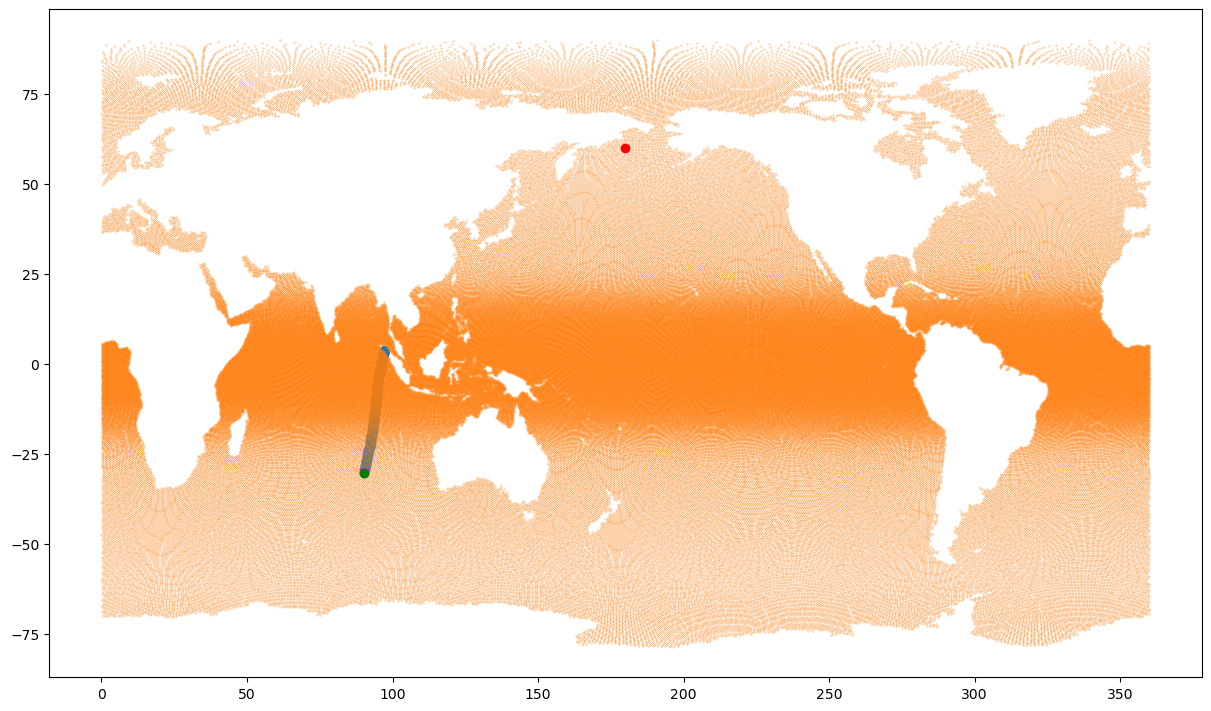

In [9]:
fig,ax = plt.subplots(nrows=1,ncols=1,constrained_layout=True,figsize=(12,7))


ax.scatter(np.rad2deg(mesh.lonVertex.isel(nVertices=np.int64(start_vertices))),np.rad2deg(mesh.latVertex.isel(nVertices=np.int64(start_vertices))))
ax.scatter(np.rad2deg(mesh.lonCell),np.rad2deg(mesh.latCell),s=0.05)

# # start
ax.scatter(np.rad2deg(mesh.lonVertex.isel(nVertices = np.int64(start_vertices[0]))),np.rad2deg(mesh.latVertex.isel(nVertices = np.int64(start_vertices[0])))
           ,color='Magenta',marker='v')

ax.scatter(np.rad2deg(mesh.lonVertex.isel(nVertices = np.int64(n_start_vertex-1))),np.rad2deg(mesh.latVertex.isel(nVertices = np.int64(n_start_vertex-1)))
           ,color='green')
# end
ax.scatter(np.rad2deg(mesh.lonVertex.isel(nVertices = np.int64(xr_end_vertex))),np.rad2deg(mesh.latVertex.isel(nVertices = np.int64(xr_end_vertex)))
           ,color='red')

# ax.set_xlim(87,92)
# ax.set_ylim(-35,-25)


In [10]:
count

1001

### do not allow transect to double back (each vertex can only be passed through once)

In [11]:
# function to calculate transect given a target start point, target end point, and ds
# def calculate_transects(target_start_lat, target_start_lon, target_end_lat, target_end_lon, ds):
# ---------- INITIATE START VERTEX ----------------
# of these transect cells, select the one that is closest to the desired starting point.
# desired values in deg
# distance_on_unit_sphere(lon1, lat1, lon2, lat 2)
# find the shortest path between the two points
# of all of the points, find the vertex that is closest to the desired start point
dist_to_start = mps.distance_on_unit_sphere(ds.lonVertex * 180/np.pi, ds.latVertex * 180/np.pi, target_start_lon, target_start_lat)
xr_start_vertex = dist_to_start.argmin()
### print('very first start vertex is ', np.int32(xr_start_vertex))
n_start_vertex = mps.xr_to_n_idx(xr_start_vertex)

start_lon = ds.isel(nVertices = xr_start_vertex).lonVertex * 180/np.pi
start_lat = ds.isel(nVertices = xr_start_vertex).latVertex * 180/np.pi

# repeat to find the vertex that is closest to the desired end point
dist_to_end = mps.distance_on_unit_sphere(ds.lonVertex * 180/np.pi, ds.latVertex * 180/np.pi, target_end_lon, target_end_lat)

# get the vertex closest to the target end lat and lon
xr_end_vertex = dist_to_end.argmin()
### print('xr_end_vertex is ', np.int32(xr_end_vertex))
end_lon = ds.isel(nVertices = xr_end_vertex).lonVertex * 180/np.pi
end_lat = ds.isel(nVertices = xr_end_vertex).latVertex * 180/np.pi

# get an array of the start and end points (this is useful if transects are broken up by land)
xr_start_end_vertices = np.array([xr_start_vertex, xr_end_vertex])

# get distance between target start point and target end point
distance = mps.distance_on_unit_sphere(start_lon, start_lat, target_end_lon, target_end_lat)

# ---------- FIND NEXT VERTEX ----------------
start_vertices = np.array([])
next_vertices = np.array([])

count=0

# while distance.min() > 10: #10000:
while count < 378:
    count += 1
    ### print(count)
    # get the edges attached to the start vertex
    n_edgesOnStartVertex = ds.edgesOnVertex.isel(nVertices = xr_start_vertex)
    xr_edgesOnStartVertex = mps.n_to_xr_idx(n_edgesOnStartVertex)
    ### print('edges attached to start vertex ', np.int32(xr_start_vertex), ' are ', xr_edgesOnStartVertex)
    
    # check that the edges you selected are connected to the start vertex (returns in n indices)
    # ds.verticesOnEdge.isel(nEdges = xr_edgesOnStartVertex[0])
    
    # for each of these edges, find the vertices they are connected to and then remove the start_vertex (we don't want to "travel back" to that vertex)
    n_vertices_nextToStartVertex = np.unique(ds.verticesOnEdge.isel(nEdges = np.int32(xr_edgesOnStartVertex)))
    xr_vertices_nextToStartVertex = mps.n_to_xr_idx(n_vertices_nextToStartVertex)
    # print(xr_vertices_nextToStartVertex)
    ### print('possible vertices to move to are ', xr_vertices_nextToStartVertex)

    used_vertices = np.union1d(start_vertices, xr_start_vertex)
    
    xr_vertices_nextToStartVertex_Use = np.delete(xr_vertices_nextToStartVertex, np.where(np.isin(xr_vertices_nextToStartVertex, used_vertices)))

    ds_vertices_nextLatLon = ds[['lonVertex','latVertex']].isel(nVertices = xr_vertices_nextToStartVertex_Use)
    # ds_vertices_nextLatLon = ds[['lonVertex','latVertex']].isel(nVertices = xr_vertices_nextToStartVertex)
    ds_vertices_nextLatLon['lonVertex'] = ds_vertices_nextLatLon.lonVertex * 180/np.pi
    ds_vertices_nextLatLon['latVertex'] = ds_vertices_nextLatLon.latVertex * 180/np.pi
    
    # calculate the distance between the next vertices and the target end
    distance = mps.distance_on_unit_sphere(ds_vertices_nextLatLon.lonVertex, ds_vertices_nextLatLon.latVertex, target_end_lon, target_end_lat)
    
    # select the nVertex that is the shortest distance from the end point
    chosen_nextVertex_arg = distance.argmin()
    n_chosen_nextVertex = distance.VertexID[chosen_nextVertex_arg]
    xr_chosen_nextVertex = mps.n_to_xr_idx(n_chosen_nextVertex)
    ### print('the chosen next vertex to move to is ', np.int32(xr_chosen_nextVertex))
    
    # ---------- UPDATE ARRAYS ----------------
    
    # store vertices
    start_vertices = np.append(start_vertices, xr_start_vertex)
    next_vertices = np.append(next_vertices, xr_chosen_nextVertex)

    xr_start_vertex = xr_chosen_nextVertex 

    # break code if the next vertex is the vertex closest to the target end lat and lon
    if xr_chosen_nextVertex == xr_end_vertex:
        print('broken because reached end vertex')
        break

# ---------- FIND EDGES OF TRANSECT ---------------- 
# We want to identify the edges that connect the vertices. The vertices are already ordered consecutively (because the transects are built from an algorithm)
# We will take advantage of this fact using a for loop to extract the edges that are shared between vertices next to each other

# modify next_vertices to also include the start vertex
next_vertices = np.insert(next_vertices, 0, mps.n_to_xr_idx(n_start_vertex))


# next vertices are in xr indices
int_next_vertices = np.int32(next_vertices)
n_transect_edges = np.array([])

for i in range(0,len(int_next_vertices)-1):
    edgesOnVertex0 = ds.edgesOnVertex.isel(nVertices = int_next_vertices[i]).values
    edgesOnVertex1 = ds.edgesOnVertex.isel(nVertices = int_next_vertices[i+1]).values
    shared_edge = np.intersect1d(edgesOnVertex0, edgesOnVertex1)
    n_transect_edges = np.append(n_transect_edges, shared_edge)

xr_transect_edges = mps.n_to_xr_idx(n_transect_edges)

    
# return xr_transect_edges, next_vertices

In [12]:
count

378

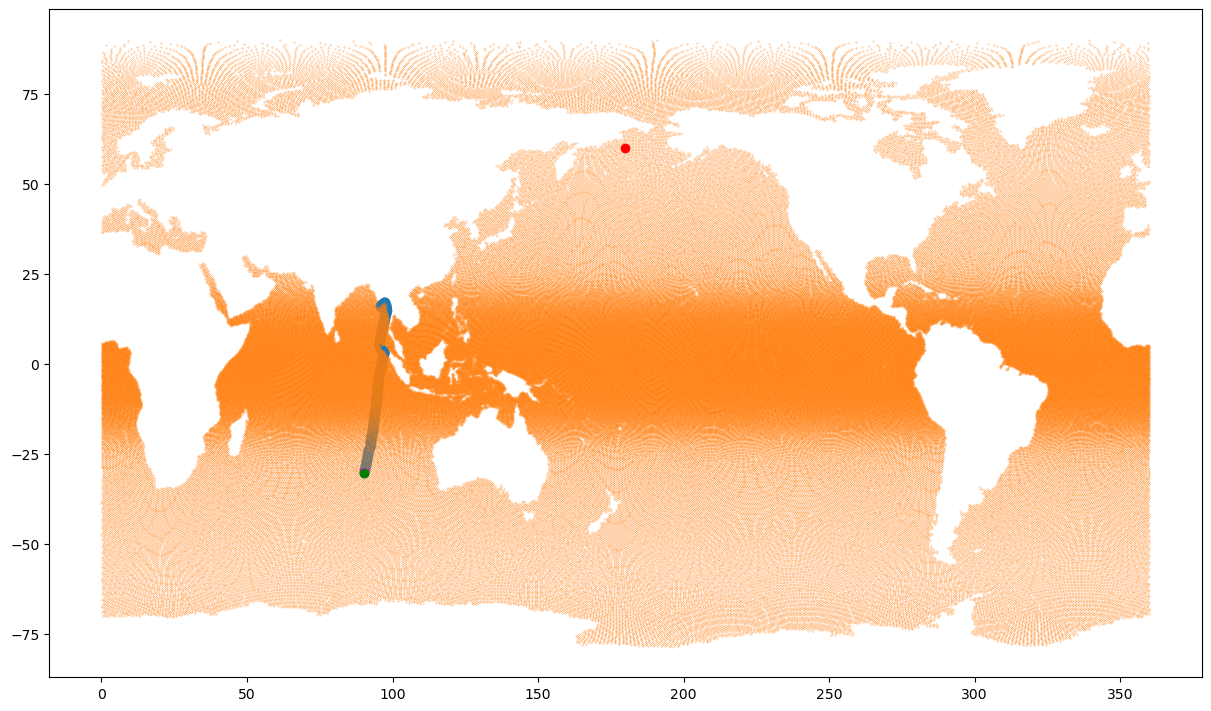

In [13]:
fig,ax = plt.subplots(nrows=1,ncols=1,constrained_layout=True,figsize=(12,7))


ax.scatter(np.rad2deg(mesh.lonVertex.isel(nVertices=np.int64(start_vertices))),np.rad2deg(mesh.latVertex.isel(nVertices=np.int64(start_vertices))))
ax.scatter(np.rad2deg(mesh.lonCell),np.rad2deg(mesh.latCell),s=0.05)

# # start
ax.scatter(np.rad2deg(mesh.lonVertex.isel(nVertices = np.int64(start_vertices[0]))),np.rad2deg(mesh.latVertex.isel(nVertices = np.int64(start_vertices[0])))
           ,color='Magenta',marker='v')

ax.scatter(np.rad2deg(mesh.lonVertex.isel(nVertices = np.int64(n_start_vertex-1))),np.rad2deg(mesh.latVertex.isel(nVertices = np.int64(n_start_vertex-1)))
           ,color='green')
# end
ax.scatter(np.rad2deg(mesh.lonVertex.isel(nVertices = np.int64(xr_end_vertex))),np.rad2deg(mesh.latVertex.isel(nVertices = np.int64(xr_end_vertex)))
           ,color='red')

# ax.set_xlim(87,92)
# ax.set_ylim(-35,-25)


In [14]:
target_start_lon

90

In [15]:
target_start_lat

-30

In [16]:
target_end_lon

180

In [17]:
target_end_lat

60